# PolyData Tutorial

## PolyDiss

Begin by downloading the PolyDiss dataset. It consists of two files: an `.lmdb` file containing the datapoints and a `.parquet` file containing the metadata.

Let's assume you have downloaded the files to:

In [1]:
data_dir = "/tmp/simpoly"

In [2]:
import os.path
import pandas as pd

from simpoly.poly_data import ArrayDictReader


dataset = ArrayDictReader(os.path.join(data_dir, "poly_diss", "poly_diss.lmdb"))
metadata = pd.read_parquet(os.path.join(data_dir, "poly_diss", "poly_diss.parquet"))

# Perform a sanity check
assert len(dataset) == len(metadata)

Next, examine a single trajectory.

Text(0, 0.5, 'Energy (eV)')

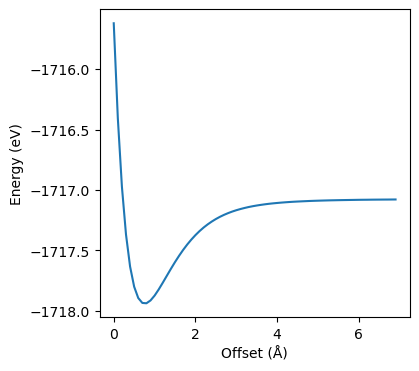

In [3]:
import matplotlib.pyplot as plt

select = (metadata["poly_id"] == "PP") & (metadata["offset_dim"] == "xyz")
ids = metadata[select].sort_values("offset")["idx"].to_list()

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(
    metadata.loc[ids, "offset"],
    [dataset[i]["energy"].item() for i in ids],
)

ax.set_xlabel("Offset (Å)")
ax.set_ylabel("Energy (eV)")

Finally, visualize the trajectories using the `simpoly.visualize` module.
Click the link to visualize the trajectory in the browser.

In [4]:
from simpoly import visualize
from simpoly.poly_data import array_dict_to_atoms

visualize.view([array_dict_to_atoms(dataset[i]) for i in ids])

Dash app running on http://localhost:8050/


## PolyPack

Next, download the PolyPack dataset. It consists of two files: an `.lmdb` file containing the datapoints and a `.parquet` file containing the metadata. Load the files and perform a sanity check.

In [5]:
dataset = ArrayDictReader(os.path.join(data_dir, "poly_pack", "poly_pack.lmdb"))
metadata = pd.read_parquet(os.path.join(data_dir, "poly_pack", "poly_pack.parquet"))

assert len(dataset) == len(metadata)

Finally, visualize the distribution of the number of atoms in the dataset.

Text(0, 0.5, 'Count')

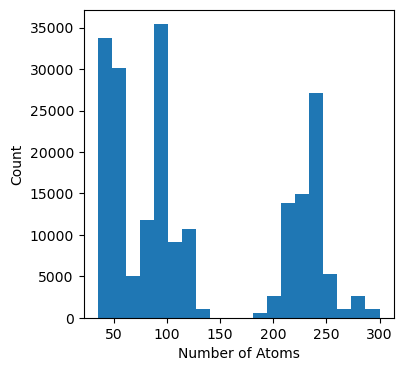

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(4, 4))

ax.hist(metadata["n_atoms"], bins=20)

ax.set_xlabel("Number of Atoms")
ax.set_ylabel("Count")

Next, examine a single trajectory from the PolyPack dataset.

Text(0, 0.5, 'Energy (eV)')

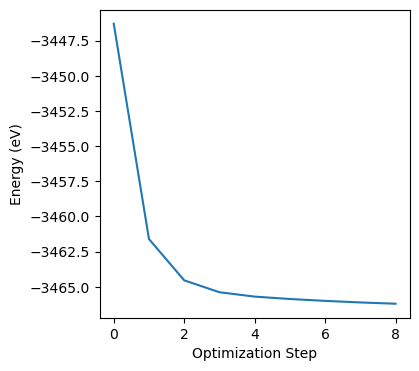

In [7]:
import matplotlib.pyplot as plt

key, traj = next(iter(metadata[metadata["poly_id"] == "PP"].groupby(["density", "seed"])))
ids = traj["idx"].to_list()

fig, ax = plt.subplots(figsize=(4, 4))

ax.plot(
    traj["opt_step"],
    [dataset[i]["energy"].item() for i in ids],
)

ax.set_xlabel("Optimization Step")
ax.set_ylabel("Energy (eV)")